In [1]:
import numpy as np
from matplotlib import pyplot as plt

## Características del material

In [2]:
# Coeficiente de corrección de corte
kappa = np.pi**2/12

# Relación entre módulo de Young y módulo de corte
E_G = 2.667

# Parámetro adimensional relacionado al corte
gamma_bs = E_G/kappa

print(f'Coeficiente de corrección de corte "kappa": {kappa}')
print(f'Parámetro adimensional propiedades de corte en vibraciones mecánicas "gamma_bs": {gamma_bs}')

Coeficiente de corrección de corte "kappa": 0.8224670334241132
Parámetro adimensional propiedades de corte en vibraciones mecánicas "gamma_bs": 3.242683161289378


## Parámetros geométricos
Se calcula el momento de inercia. Luego se recalculan los radios característicos para L=1000 mm.

In [3]:
# Sección [m^2]
A = 2.54e-5

# Longitud [m]
L_0 = 0.366
L_1 = 1

# Radio de giro adimensional p/L=366 mm
# R0_0 = np.sqrt(3.6*10**(-3))


# Radio de giro p/L=366 [mm]
# r0 = R0_0*L_0

# Momento de inercia [mm^4]
# I1 = r0**2*A
I = 3.12e-7

r02 = I/A
R02 = r02/(L_1**2)

# Cuadrado del radio de giro adimensional p/L=1000 mm
# R02_1 = (r0/L_1)**2

# print(f'Momento de inercia "I1": {I1} mm^4')
print(r02)
print(R02)
print(gamma_bs*R02)
print(gamma_bs*R02**2)
print(f'Momento de inercia "I": {I} m^4')
# print(f'Radio de giro "r_0": {r0} mm')
# print(f'Cuadrado del radio de giro adimensional para L=1000 mm R_0^2: {R02_1}')
print(f'Cuadrado del radio de giro adimensional R_0^2: {R02:.4f}')

0.012283464566929133
0.012283464566929133
0.03983138371347582
0.0004892673904962384
Momento de inercia "I": 3.12e-07 m^4
Cuadrado del radio de giro adimensional R_0^2: 0.0123


## Tiempo característico de la viga


In [4]:
# Módulo de Young [N/m^2]
E = 207e9

# densidad acero [kg/m3]
rho = 7680

# Tiempo característico de la viga para L=1m [s]
t0 = np.sqrt(((rho)*A*L_1**4)/(E*I))
print(f'Tiempo característico para L=1m "t_0": {t0:.3f} s')

Tiempo característico para L=1m "t_0": 0.002 s


In [5]:
# T para t final 0s
t_1 = 10
T_1 = t_1/t0
print(f'Límite del dominio adimensional del tiempo: {T_1:.2f}')

Límite del dominio adimensional del tiempo: 5753.94


## Elasticidades Chung
Reajuste de las elasticidades adimensionales de la longitud de 0.366mm a 1m. Se busca conservar el valor original de las elasticidades de los soportes.

In [6]:
# Elasticidad lineal adimensional p/L_0
K_L0 = 1000.0
K_10 = 200.0

# Elasticidad torcional adimensional p/L_0
K_tL0 = 10.0
K_t10 = 2.0

# Elasticidad lineal [N/m]
k_L = K_L0*E*I/L_0**3
k_1 = K_10*E*I/L_0**3

# Elasticidad torcional [N.m]
k_tL = K_tL0*E*I/L_0
k_t1 = K_t10*E*I/L_0

# Elasticidad lineal adimensional para L_1
K_L1 = k_L*L_1**3/(E*I)
K_11 = k_1*L_1**3/(E*I)

# Elasticidad torcional adimensional para L_1
K_tL1 = k_tL*L_1/(E*I)
K_t11 = k_t1*L_1/(E*I)

print(f'Elasticidad lineal apoyos: {k_L:.2e} N/m')
print(f'Elasticidad torcional apoyos: {k_tL:.2e} N.m')
print(f'Elasticidad lineal puntual: {k_1:.2e} N/m')
print(f'Elasticidad torcional puntual: {k_tL:.2e} N.m')
print('-----------------------------------------------------------------')
print('-----------------------------------------------------------------')
print(f'Elasticidad lineal adimensional para L=1 mm: {round(K_L1,2)}')
print(f'Elasticidad torcional adimensional para L=1 mm: {round(K_tL1,2)}')
print(f'Elasticidad lineal adimensional puntual para L=1 mm: {round(K_11,2)}')
print(f'Elasticidad torcional adimensional puntual para L=1 mm: {round(K_t11,2)}')

Elasticidad lineal apoyos: 1.32e+09 N/m
Elasticidad torcional apoyos: 1.76e+06 N.m
Elasticidad lineal puntual: 2.63e+08 N/m
Elasticidad torcional puntual: 1.76e+06 N.m
-----------------------------------------------------------------
-----------------------------------------------------------------
Elasticidad lineal adimensional para L=1 mm: 20396.55
Elasticidad torcional adimensional para L=1 mm: 27.32
Elasticidad lineal adimensional puntual para L=1 mm: 4079.31
Elasticidad torcional adimensional puntual para L=1 mm: 5.46


## Elasticidades
Selección de elasticidades para 1m.

In [7]:
# Elasticidad lineal [N/m]
k_L_s =7e5
k_1_s = 0

# Elasticidad torcional [N.m]
k_tL_s = 9e4
k_t1_s = 0

# Elasticidad lineal [N/m]
k_R_s =1e10

# Elasticidad torcional [N.m]
k_tR_s = 9e4


# Elasticidad lineal adimensional para L_1
K_L1_s = k_L_s*L_1**3/(E*I)
K_11_s = k_1_s*L_1**3/(E*I)

# Elasticidad torcional adimensional para L_1
K_tL1_s = k_tL_s*L_1/(E*I)
K_t11_s = k_t1_s*L_1/(E*I)

# Elasticidad lineal adimensional para L_1
K_R1_s = k_R_s*L_1**3/(E*I)

# Elasticidad torcional adimensional para L_1
K_tR1_s = k_tR_s*L_1/(E*I)


print(f'Elasticidad lineal apoyos L: {k_L_s:.2e} N/m')
print(f'Elasticidad torcional apoyos L: {k_tL_s:.2e} N.m')
print(f'Elasticidad lineal apoyos R: {k_R_s:.2e} N/m')
print(f'Elasticidad torcional apoyos R: {k_tR_s:.2e} N.m')
print(f'Elasticidad lineal puntual: {k_1_s:.2e} N/m')
print(f'Elasticidad torcional puntual: {k_tL_s:.2e} N.m')
print('-----------------------------------------------------------------')
print('-----------------------------------------------------------------')
print(f'Elasticidad lineal adimensional L para L=1 m: {round(K_L1_s,2)}')
print(f'Elasticidad torcional adimensional L para L=1 m: {round(K_tL1_s,2)}')
print(f'Elasticidad lineal adimensional R para L=1 m: {round(K_R1_s,2)}')
print(f'Elasticidad torcional adimensional R para L=1 m: {round(K_tR1_s,2)}')
print(f'Elasticidad lineal adimensional puntual para L=1 m: {round(K_11_s,2)}')
print(f'Elasticidad torcional adimensional puntual para L=1 m: {round(K_t11_s,2)}')

Elasticidad lineal apoyos L: 7.00e+05 N/m
Elasticidad torcional apoyos L: 9.00e+04 N.m
Elasticidad lineal apoyos R: 1.00e+10 N/m
Elasticidad torcional apoyos R: 9.00e+04 N.m
Elasticidad lineal puntual: 0.00e+00 N/m
Elasticidad torcional puntual: 9.00e+04 N.m
-----------------------------------------------------------------
-----------------------------------------------------------------
Elasticidad lineal adimensional L para L=1 m: 10.84
Elasticidad torcional adimensional L para L=1 m: 1.39
Elasticidad lineal adimensional R para L=1 m: 154837.11
Elasticidad torcional adimensional R para L=1 m: 1.39
Elasticidad lineal adimensional puntual para L=1 m: 0.0
Elasticidad torcional adimensional puntual para L=1 m: 0.0


## Masa puntual
Reajuste del valor adimensional de la masa puntual, conservando el valor original de la masa

In [8]:
# Masa de la viga [kg]
m_b0 = (rho)*A*L_0 # L=0.366 m
m_b1 =(rho)*A*L_1 # L=1 m

# Masa puntual [kg]
m_10 = 14.01 # valor adimensional para L=0.366m
M_1 = m_b0*m_10 # valor original

# Masa adimensional p/L=1 m
m_11 = M_1/m_b1

print(f'masa puntual: {M_1} kg')
print(f'masa puntual adimemsional para L=1 m: {m_11:.2f}')

masa puntual: 1.00026289152 kg
masa puntual adimemsional para L=1 m: 5.13


## Fuerza de excitación

In [16]:
# módulo de la fuerza de excitación [N/m]
f_a = 20000
F_am = f_a*L_1**3/(E*I)

print(f'módulo de la fuerza de excitación: {f_a:.2e} N/m')
print(f'módulo de la fuerza de excitación adimensional: {F_am:.2e}')

módulo de la fuerza de excitación: 2.00e+04 N/m
módulo de la fuerza de excitación adimensional: 3.10e-01


In [10]:
X= np.linspace(0, 1, 100).reshape(-1,1)
T= np.linspace(0, T_1, 100).reshape(-1,1)
X_m, T_m = np.meshgrid(X, T)

C = 2*np.pi
print(f'Factor C: {C:.2f}')
print(f'Ciclos: {C/(2*np.pi):.2f}')
print(f'Frecuencia: {(C/(2*np.pi)/t_1):.2f}')
# F = (1-16*np.pi**2)*np.sin(X_m)*np.cos(4*np.pi**T_m)
F_a = F_am*np.sin(C*T_m/T_1)
# F_a = F_am*np.sin(3*np.pi*T_m/T_1)

Factor C: 6.28
Ciclos: 1.00
Frecuencia: 0.10


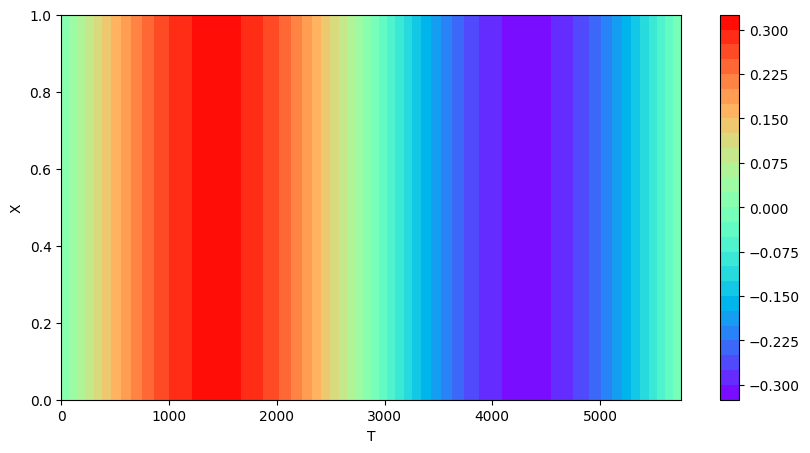

In [11]:
fig, ax = plt.subplots(figsize=(10,5))
heatmap = ax.contourf(T_m, X_m, F_a, levels=25, cmap='rainbow')
cbar = fig.colorbar(heatmap, ax=ax, orientation='vertical')
ax.set_xlabel('T')
ax.set_ylabel('X')
plt.show()

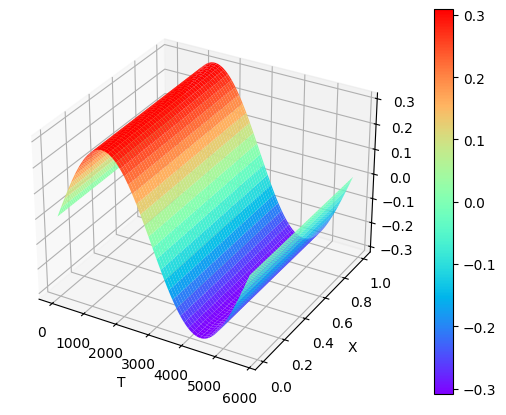

In [12]:
fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": "3d"})
heatmap = ax.plot_surface(T_m, X_m, F_a, cmap='rainbow')
cbar = fig.colorbar(heatmap, ax=ax, orientation='vertical')
ax.set_xlabel('T')
ax.set_ylabel('X')
plt.show()

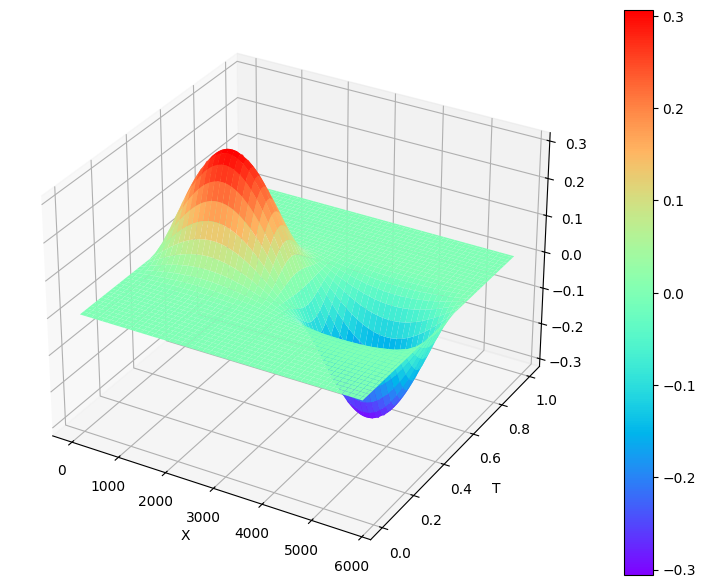

In [13]:
# Parámetros
x_pos = 0.5
sigma_pos = 0.08

# Gaussiana centrada en x_pos
g = np.exp(-((X_m - x_pos)**2) / (2 * sigma_pos**2))

F_ag = F_am * np.sin(C * T_m / T_1) * g

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
heatmap = ax.plot_surface(T_m, X_m, F_ag, cmap='rainbow')
cbar = fig.colorbar(heatmap, ax=ax, orientation='vertical')

ax.set_xlabel('X')
ax.set_ylabel('T')

plt.tight_layout()
plt.show()

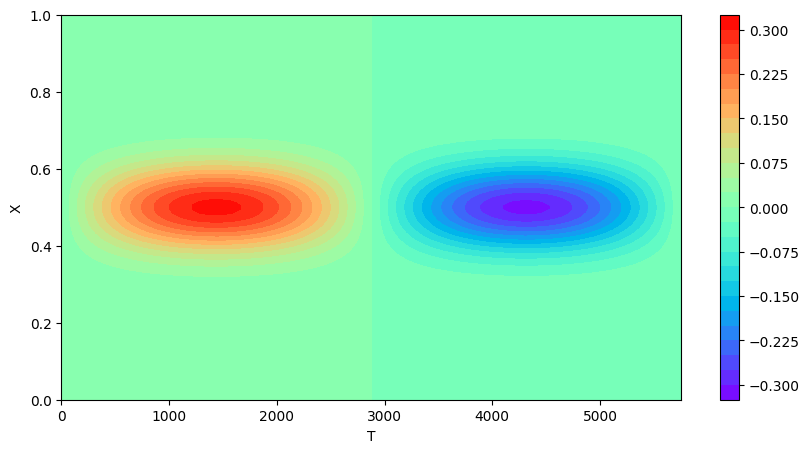

In [14]:
fig, ax = plt.subplots(figsize=(10,5))
heatmap = ax.contourf(T_m, X_m, F_ag, levels=25, cmap='rainbow')
cbar = fig.colorbar(heatmap, ax=ax, orientation='vertical')
ax.set_xlabel('T')
ax.set_ylabel('X')
plt.show()